In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [25]:
data = {
    'Day' : np.arange(1,11),
    'Distance_km' : [5,8,10,12,15,18,22,27,35,50],
    'Orders' : [10,15,20,25,30,35,40,45,50,55],
    'Revenue' : [1000,1500,2000,2600,3300,4200,5500,7200,9800,15000],
}

In [26]:
df = pd.DataFrame(data)
df

,Day,Distance_km,Orders,Revenue
0,1,5,10,1000
1,2,8,15,1500
2,3,10,20,2000
3,4,12,25,2600
4,5,15,30,3300
5,6,18,35,4200
6,7,22,40,5500
7,8,27,45,7200
8,9,35,50,9800
9,10,50,55,15000


In [27]:
df.corr()

,Day,Distance_km,Orders,Revenue
Day,1.000000,0.93972,1.000000,0.916248
Distance_km,0.939720,1.00000,0.939720,0.997720
Orders,1.000000,0.93972,1.000000,0.916248
Revenue,0.916248,0.99772,0.916248,1.000000


In [61]:
# prediction -1 

X = df[['Distance_km','Orders']] # independent value
Y = df[['Revenue']] # dependent value

In [81]:
# prediction -2

X1 = df[['Day','Distance_km','Orders']] # independent value
Y1 = df[['log_revenue']] # dependent value

In [63]:
# turning the Y values into the model format
# X_const = sm.add_constant(X)

In [64]:
# prediction - 1
# then passing the X and Y values to the model
model = sm.OLS(Y, X) # using Ordinary Least Square model 

In [65]:
# prediction - 2
# then passing the X and Y values to the model
model1 = sm.OLS(Y1, X1) # using Ordinary Least Square model 

In [66]:
result = model.fit() # this fit is the model train

In [67]:
results = model1.fit()

In [68]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                Revenue   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                              4092.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):                    9.10e-13
Time:                        12:27:29   Log-Likelihood:                         -67.595
No. Observations:                  10   AIC:                                      139.2
Df Residuals:                       8   BIC:                                      139.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Distance_km   392.8122     13.377     29.364      0.000     361.964     423.660
Orders        -82.0212      9.083     -9.031      0.000    -102.966     -61.077
==============================================================================
Omnibus:                        0.014   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.993   Jarque-Bera (JB):                0.238
Skew:                           0.012   Prob(JB):                        0.888
Kurtosis:                       2.244   Cond. No.                         9.31
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_revenue   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1058.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           2.06e-09
Time:                        12:27:30   Log-Likelihood:                 16.491
No. Observations:                  10   AIC:                            -26.98
Df Residuals:                       7   BIC:                            -26.07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Day            -6.4779      0.053   -121.820      0.000      -6.604      -6.352
Distance_km     0.0080      0.004      2.059      0.078      -0.001       0.017
Orders          1.3449      0.008    166.460      0.000       1.326       1.364
==============================================================================
Omnibus:                        2.527   Durbin-Watson:                   1.134
Prob(Omnibus):                  0.283   Jarque-Bera (JB):                0.994
Skew:                          -0.772   Prob(JB):                        0.608
Kurtosis:                       2.968   Cond. No.                         132.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
# Assumption for linear regression :

In [71]:
# linearity : 

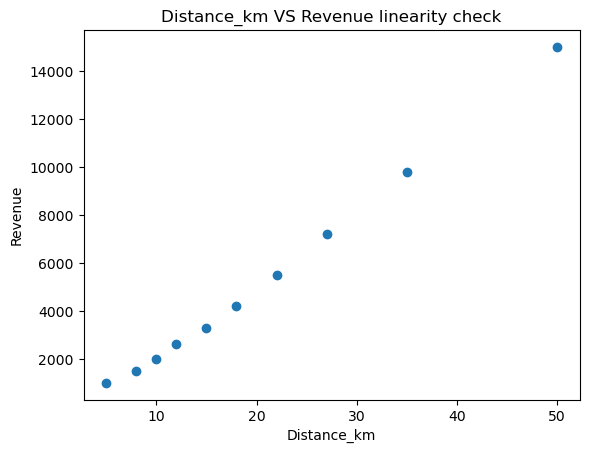

In [72]:
plt.scatter(
    df['Distance_km'],
    df['Revenue']
)

plt.xlabel('Distance_km')
plt.ylabel('Revenue')
plt.title('Distance_km VS Revenue linearity check')
plt.show()

In [73]:
# LORGARITHMS CONCEPTS :

# applying log in revenue for give a equal space for distance
# the log meaning :

# Scaling Large Ranges: For features with wide ranges (e.g. 1 to 1,000,000), 
# applying a logarithm compresses the range, allowing models to learn better without being biased by high-magnitude data points.

# here log(e) which is the log e , the base is e - exponent having the default value is 2.71828. here np.log default base value is 2.71828
# np.log(df['Revenue'])

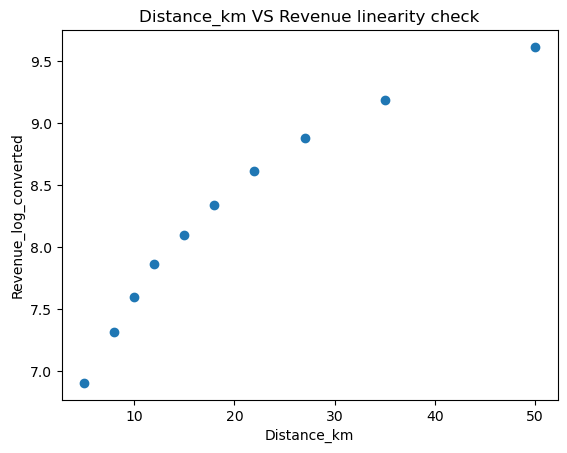

In [74]:
df['log_revenue'] = np.log(df['Revenue'])

plt.scatter(
    df['Distance_km'],
    df['log_revenue']
)

plt.xlabel('Distance_km')
plt.ylabel('Revenue_log_converted')
plt.title('Distance_km VS Revenue linearity check')
plt.show()

In [75]:
df['log_revenue']

0    6.907755
1    7.313220
2    7.600902
3    7.863267
4    8.101678
5    8.342840
6    8.612503
7    8.881836
8    9.190138
9    9.615805
Name: log_revenue, dtype: float64

In [76]:
df

,Day,Distance_km,Orders,Revenue,log_revenue
0,1,5,10,1000,6.907755
1,2,8,15,1500,7.313220
2,3,10,20,2000,7.600902
3,4,12,25,2600,7.863267
4,5,15,30,3300,8.101678
5,6,18,35,4200,8.342840
6,7,22,40,5500,8.612503
7,8,27,45,7200,8.881836
8,9,35,50,9800,9.190138
9,10,50,55,15000,9.615805


In [77]:
# Independence of Errors

In [78]:
# prediction - 1

df['predicted_revenue1'] = result.predict(X)

In [79]:
df['residue'] = df['Revenue'] - df['predicted_revenue1']

In [80]:
df

,Day,Distance_km,Orders,Revenue,log_revenue,predicted_revenue1,residue
0,1,5,10,1000,6.907755,1143.848794,-143.848794
1,2,8,15,1500,7.313220,1912.179316,-412.179316
2,3,10,20,2000,7.600902,2287.697588,-287.697588
3,4,12,25,2600,7.863267,2663.215860,-63.215860
4,5,15,30,3300,8.101678,3431.546382,-131.546382
5,6,18,35,4200,8.342840,4199.876904,0.123096
6,7,22,40,5500,8.612503,5361.019676,138.980324
7,8,27,45,7200,8.881836,6914.974697,285.025303
8,9,35,50,9800,9.190138,9647.366467,152.633533
9,10,50,55,15000,9.615805,15129.443985,-129.443985


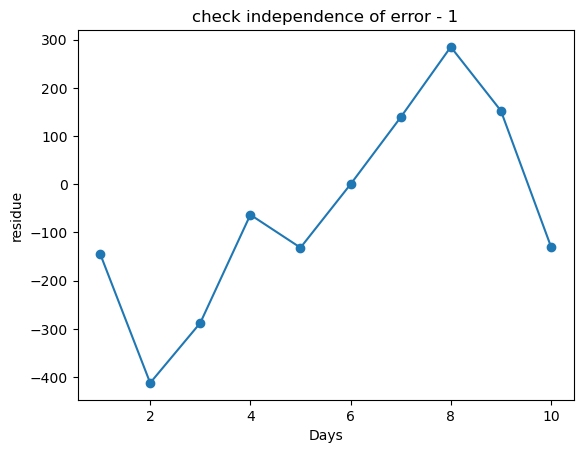

In [32]:
plt.plot(df['Day'],df['residue'], marker = 'o')

plt.title('check independence of error - 1')
plt.xlabel('Days')
plt.ylabel('residue')
plt.show()

In [33]:
# prediction - 2


df['predicted_revenue2'] = results.predict(X1)
df['residuals'] = df['log_revenue'] - df['predicted_revenue2']
df

,Day,Distance_km,Orders,Revenue,log_revenue,predicted_revenue1,residue,predicted_revenue2,residuals
0,1,5,10,1000,6.907755,1143.848794,-143.848794,7.011281,-0.103526
1,2,8,15,1500,7.313220,1912.179316,-412.179316,7.281963,0.031258
2,3,10,20,2000,7.600902,2287.697588,-287.697588,7.544617,0.056286
3,4,12,25,2600,7.863267,2663.215860,-63.215860,7.807270,0.055996
4,5,15,30,3300,8.101678,3431.546382,-131.546382,8.077952,0.023726
5,6,18,35,4200,8.342840,4199.876904,0.123096,8.348633,-0.005793
6,7,22,40,5500,8.612503,5361.019676,138.980324,8.627342,-0.014839
7,8,27,45,7200,8.881836,6914.974697,285.025303,8.914079,-0.032242
8,9,35,50,9800,9.190138,9647.366467,152.633533,9.224898,-0.034760
9,10,50,55,15000,9.615805,15129.443985,-129.443985,9.591911,0.023895


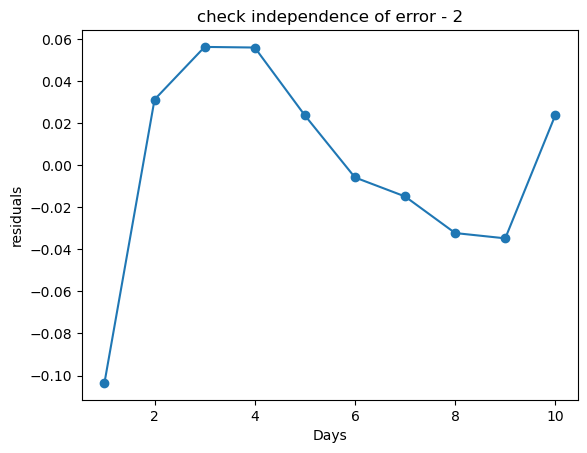

In [34]:
plt.plot(df['Day'],df['residuals'], marker = 'o')

plt.title('check independence of error - 2')
plt.xlabel('Days')
plt.ylabel('residuals')
plt.show()

In [41]:
data = {'Actual Data' : [5,10,20,30], 'Predicted Data' : [10,20,30,50]}

In [42]:
df = pd.DataFrame(data)

In [50]:
df['residue'] = df['Actual Data'] - df['Predicted Data']

In [51]:
df

,Actual Data,Predicted Data,residue
0,5,10,-5
1,10,20,-10
2,20,30,-10
3,30,50,-20


In [ ]:
# Homoscedasticity : 

In [3]:
# Homoscedasticity & hetroscedasticity
# hetroscedasticity, itho opposite tha Homoscedasticity

data3 = {'Actual Data' : [5,10,20,30,40,50,60], 'Predicted Data' : [3,7,10,20,30,10,120]}
df3 = pd.DataFrame(data3)
df3['residue'] = df3['Actual Data'] - df3['Predicted Data']
df3

,Actual Data,Predicted Data,residue
0,5,3,2
1,10,7,3
2,20,10,10
3,30,20,10
4,40,30,10
5,50,10,40
6,60,120,-60


<Axes: ylabel='Frequency'>

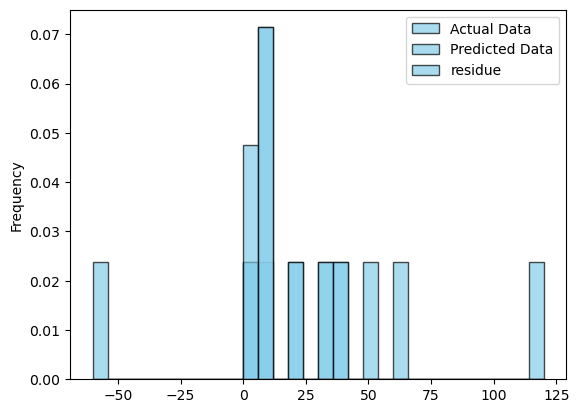

In [5]:
df3.plot.hist(bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

<Axes: title={'center': 'Density Plot (Bell Curve)'}, ylabel='Density'>

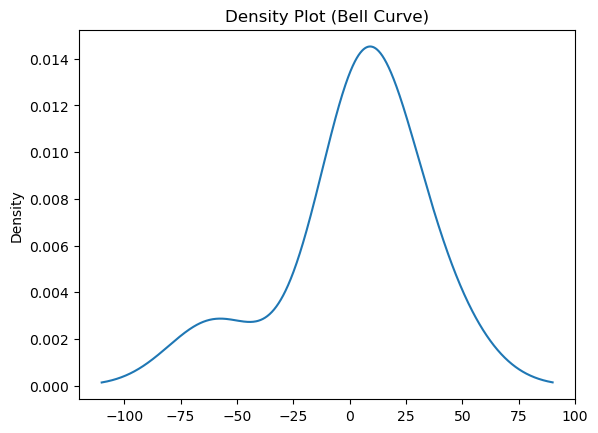

In [6]:
df3['residue'].plot.kde(title='Density Plot (Bell Curve)')

<Axes: ylabel='Density'>

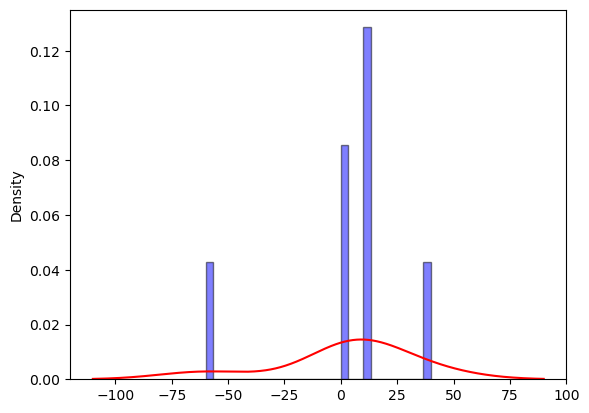

In [8]:
df3['residue'].plot(kind='hist', density=True, bins=30, alpha=0.5, color='blue', edgecolor='black', label='Histogram')
df3['residue'].plot(kind='kde', color='red', label='Bell Curve (KDE)')


In [ ]:
# multicollenarity: 